### Imports, measurement simulation, Zero-filled and GRAPPA reconstructions

In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from mrinufft import get_operator
from mrinufft.io import read_trajectory
from baselines.grappa_reconstruction import do_grappa_and_append_data
from utils import MRINUFFTPhysicsRI, ri_to_complex, complex_to_ri, psnr, ssim, sum_of_squares, _load_volumes, PSNR_MRI, L2_precon
from reg_architectures import WCRR3D
from deepinv.optim.prior import PnP, TVPrior, WaveletPrior
from baselines.drunet.drunet_base import DRUNet
from evaluation.nmAPG3d_evaluation import reconstruct_nmAPG
import deepinv as dinv
from mrinufft import get_density
import os
import warnings
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
warnings.filterwarnings("ignore")
torch.random.manual_seed(0)  # make results deterministic

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
backend = "gpunufft"
scaler = 1e-6 
noise_level = 2e-3

# Load trajectory and get the k-space locations
traj, traj_params = read_trajectory("trajectory.bin", dwell_time=0.01/2)
traj = traj.copy()
traj[traj < -0.5] = -0.5
traj[traj > 0.5] = 0.5
dim = traj_params["dimension"]
kspace_loc = traj.reshape(-1, dim)

# The chosen volume
coils = 32 # number of coils in the volume (12 or 32)
root = f"../../../../../../../../LOCAL/mri_data/Test/{coils}coil"
volume = 'e14078s3_P02048.7.h5' if coils==12 else 'e16324s3_P17408.7.h5' # The latter is a 32-coil volume
x = torch.from_numpy(scaler * np.moveaxis(_load_volumes(os.path.join(root, volume)),-1, 0)) #[coils,H,W,D] and complex dtype
#x = torch.from_numpy(1e-6 * np.moveaxis(np.load("../../../../../../../../LOCAL/mri_data/Val/_images/e15652s4_P45056.7.h5.npy"),(-1,), (0,)))

# Forward NUFFT that takes coil images -> k-space
print(f"Simulation of the undersampled measurement!")
print("Start ... ")
F_raw = get_operator(backend)(kspace_loc, x.shape[1:], n_coils=coils, density=True)
y_np = F_raw.op(x) # simulates the undersampled kspace volume y. The zero-filled recon comes from it
y_np = y_np + noise_level * torch.randn_like(y_np)
print("Succesfully simulated!")

# GRAPPA reconstruct the center of k-space and append the data, basis for our regularizers
new_kspace_loc, y_grappa = do_grappa_and_append_data(kspace_loc, y_np, traj_params, af=(2, 2), acs=None)

# Build reconstruction operator that ESTIMATES smaps from y_grappa
print(f"Operator definition, DCp weights and smaps estimation from measurement!")
print("Start ... ")

density = get_density(
    "pipe",          # or "voronoi"
    new_kspace_loc,
    x.shape[1:],
    backend=backend,   # gpunufft
    num_iterations=10 # reduce if needed
).astype(np.float32)
weights = torch.from_numpy(density).to(device)
data_fidelity = L2_precon(weights) # custom data fidelity

E_est = get_operator(backend)(
    new_kspace_loc,
    x.shape[1:],
    n_coils=coils,
    smaps={"name": "low_frequency", "kspace_data": y_grappa},
    density= False,#density,#True,
    use_gpu_direct=True,
)
physics = MRINUFFTPhysicsRI(E_est)
print("Succesfull!")

y = torch.from_numpy(y_grappa).to(device) # ACS reconstructed with grappa (In the k-space)
x_adj_ri = physics.A_adjoint(y) # Grappa recon without DCp

# Reference/Ground Truth (Adjoint coil combination)
smaps = torch.from_numpy(E_est.smaps)
x_gt = torch.sum(torch.conj(smaps) * x, axis=0)
x_gt_ri = complex_to_ri(x_gt).to(device) # In the RI space

# Compute the magnitudes
reference = torch.abs(ri_to_complex(x_gt_ri)).detach().cpu()
# Grappa + DCp recon
dcp_x_adj_ri = physics.A_adjoint(weights * y)
grappa_recon  = torch.abs(ri_to_complex(dcp_x_adj_ri)).detach().cpu()
# Handle the zero-filled + DCp recon
x_zf = F_raw.adj_op(y_np) #zero-filled reconstruction
zf_recon = sum_of_squares(x_zf) # Its magnitude 

Simulation of the undersampled measurement!
Start ... 
Succesfully simulated!


100%|███████████████████████████████████████████| 77/77 [00:15<00:00,  5.08it/s]


Operator definition, DCp weights and smaps estimation from measurement!
Start ... 
Succesfull!


### PnP-DRUNet reconstruction 

In [3]:
# Load the DRUNet weights
drunet = DRUNet(in_channels=2, out_channels=2, dim=3, pretrained=None).to(device)
weights = "weights/drunet/drunet_3d_complex_denoise.pth"
state_dict = torch.load(weights, map_location=device, weights_only=True)
drunet.load_state_dict(state_dict)
denoiser = drunet.eval().to(device)
prior = PnP(denoiser=denoiser)

In [4]:
from deepinv.optim import ADMM#, HQS
max_iter = 100

# instantiate the algorithm class to solve the IP problem.
model = ADMM(
    prior=prior,
    data_fidelity=data_fidelity,
    g_first=False,
    stepsize=2.5,
    sigma_denoiser=0.01,
    early_stop=True,
    max_iter=max_iter,
    crit_conv="residual",
    thres_conv=1e-3,#1e-7,
    verbose=True,
    show_progress_bar = True,
)
model.psnr = PSNR_MRI()

with torch.no_grad():
    x_rec_ri, drunet_metrics = model(y, physics, x_gt=x_gt_ri, compute_metrics=True)

# Its Magnitude
drunet_recon  = torch.abs(ri_to_complex(x_rec_ri)).detach().cpu()

100%|█████████████████████████████████████████| 100/100 [16:23<00:00,  9.83s/it]


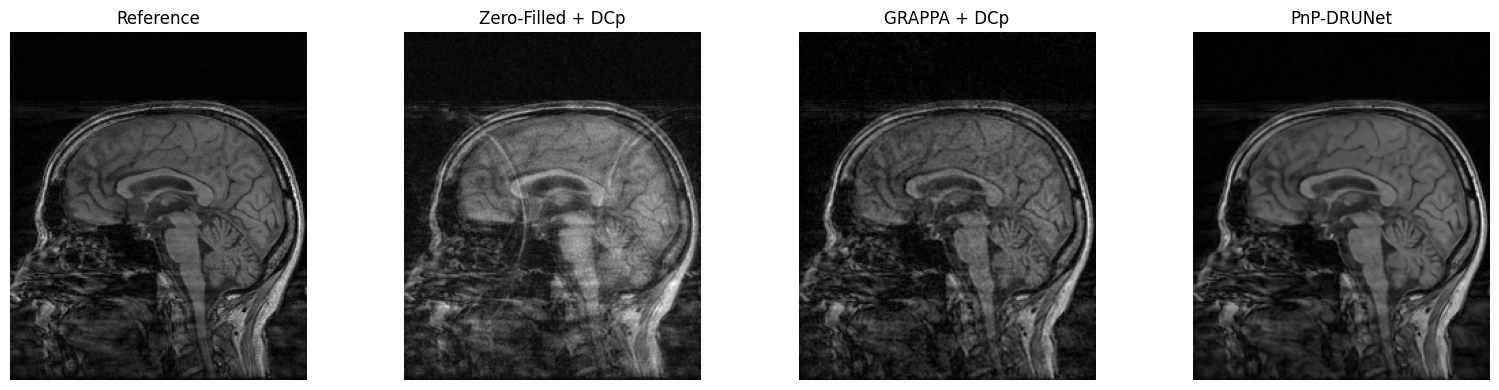

In [9]:
# Plots (sagittal mid-slice)
mid =  x.shape[-1] // 2
plt.figure(figsize=(16,4))
plt.subplot(1,4,1); plt.imshow(reference[..., mid], cmap='gray'); plt.title('Reference'); plt.axis('off')
plt.subplot(1,4,2); plt.imshow(zf_recon[..., mid],  cmap='gray'); plt.title('Zero-Filled + DCp'); plt.axis('off')
plt.subplot(1,4,3); plt.imshow(grappa_recon[..., mid],  cmap='gray'); plt.title('GRAPPA + DCp'); plt.axis('off')
plt.subplot(1,4,4); plt.imshow(drunet_recon[..., mid],  cmap='gray'); plt.title('PnP-DRUNet'); plt.axis('off')
plt.tight_layout(); plt.show()

### $\ell_1$-wavelet reconstruction

In [5]:
from deepinv.optim import ADMM

# Define the l1-wavelets prior
prior = WaveletPrior(level=4, wv="db4", p=1, wvdim=3, device=device)
max_iter = 100

# Instantiate the algorithm class to solve the IP problem.
model = ADMM(
    prior=prior,
    g_first=False,
    data_fidelity=data_fidelity,
    stepsize=1.0,
    lambda_reg=3.8e-2,
    early_stop=True,
    max_iter=max_iter,
    crit_conv="residual",
    thres_conv=1e-3,#1e-7,
    verbose=True,
    show_progress_bar=True,
)
model.psnr = PSNR_MRI()

with torch.no_grad():
    x_rec_ri, wv_metrics = model(y, physics, x_gt=x_gt_ri, compute_metrics=True)

# Its Magnitude
wv_recon  = torch.abs(ri_to_complex(x_rec_ri)).detach().cpu()

100%|█████████████████████████████████████████| 100/100 [07:30<00:00,  4.51s/it]


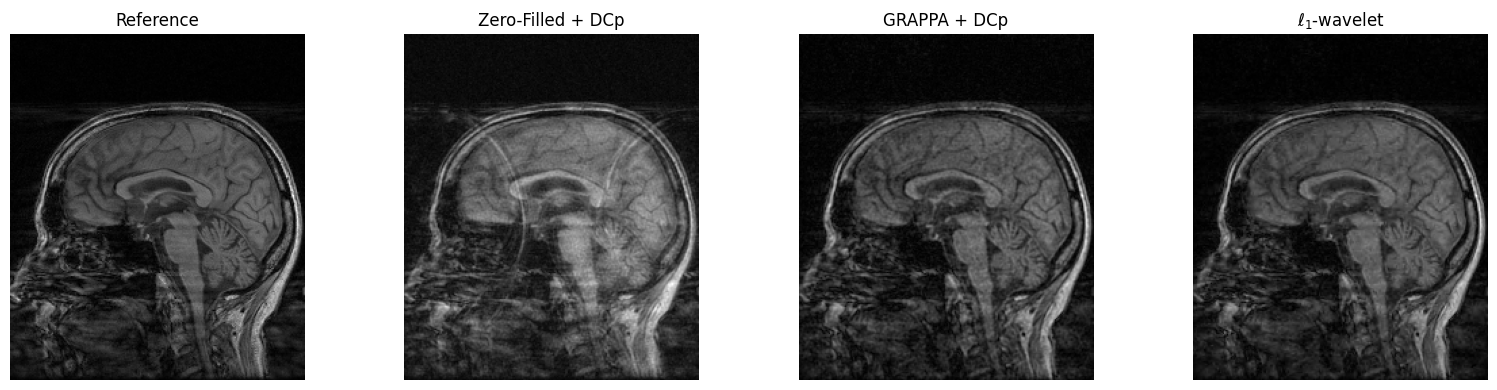

In [17]:
# Plots (sagittal mid-slice)
mid =  x.shape[-1] // 2
plt.figure(figsize=(16,4))
plt.subplot(1,4,1); plt.imshow(reference[..., mid], cmap='gray'); plt.title('Reference'); plt.axis('off')
plt.subplot(1,4,2); plt.imshow(zf_recon[..., mid],  cmap='gray'); plt.title('Zero-Filled + DCp'); plt.axis('off')
plt.subplot(1,4,3); plt.imshow(grappa_recon[..., mid],  cmap='gray'); plt.title('GRAPPA + DCp'); plt.axis('off')
plt.subplot(1,4,4); plt.imshow(wv_recon[..., mid],  cmap='gray'); plt.title(r'$\ell_1$-wavelet'); plt.axis('off')
plt.tight_layout(); plt.show()

### TV reconstruction

In [6]:
from deepinv.optim import ADMM

# Define the TV prior
prior = TVPrior(def_crit=1e-4)
max_iter = 100

# Instantiate the algorithm class to solve the IP problem.
model = ADMM(
    prior=prior,
    g_first=False,
    data_fidelity=data_fidelity,
    stepsize=1.0,
    lambda_reg=1.3e-3,
    early_stop=True,
    max_iter=max_iter,
    crit_conv="residual",
    thres_conv=1e-3,#1e-7,
    verbose=True,
    show_progress_bar = True,
)
model.psnr = PSNR_MRI()

with torch.no_grad():
    x_rec_ri, tv_metrics = model(y, physics, x_gt=x_gt_ri, compute_metrics=True)

# Its Magnitude
tv_recon  = torch.abs(ri_to_complex(x_rec_ri)).detach().cpu()

100%|█████████████████████████████████████████| 100/100 [07:48<00:00,  4.69s/it]


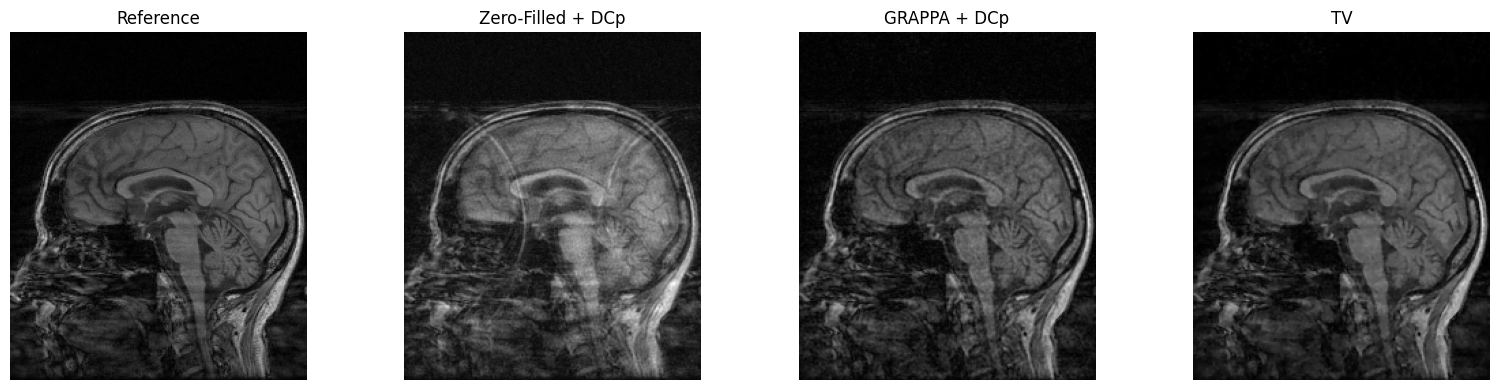

In [13]:
# Plots (sagittal mid-slice)
mid =  x.shape[-1] // 2
plt.figure(figsize=(16,4))
plt.subplot(1,4,1); plt.imshow(reference[..., mid], cmap='gray'); plt.title('Reference'); plt.axis('off')
plt.subplot(1,4,2); plt.imshow(zf_recon[..., mid],  cmap='gray'); plt.title('Zero-Filled + DCp'); plt.axis('off')
plt.subplot(1,4,3); plt.imshow(grappa_recon[..., mid],  cmap='gray'); plt.title('GRAPPA + DCp'); plt.axis('off')
plt.subplot(1,4,4); plt.imshow(tv_recon[..., mid],  cmap='gray'); plt.title('TV'); plt.axis('off')
plt.tight_layout(); plt.show()

### WCRR reconstruction (rotation-invariant version)

In [3]:
# Load the regularizer weights
regularizer = WCRR3D(weak_convexity=1.0, nb_channels=[2,4,8,32], filter_sizes=[3, 3, 3], rotations=True).to(device)
pretrained = "weights/bilevel_Denoising/WCRR_bilevel_IFT_ckpt_100.pt"
regularizer.load_state_dict(torch.load(pretrained, weights_only=True, map_location=device))
regularizer.eval()

# Parameters of nmAPG solver
step_size = 1e-1
max_iter = 100
tol = 1e-3 #1e-7

# Hyperparameters
lmbd = 0.07
sigma = 0.035
sigma = torch.tensor([sigma], device=device)

with torch.no_grad():
    x_rec_ri, wcrr_metrics = reconstruct_nmAPG(
                sigma,
                y,
                physics,
                data_fidelity,
                regularizer,
                lmbd,
                step_size,
                max_iter,
                tol,
                verbose=True,
                x_init=x_adj_ri, #Initialize as GRAPPA recon (or with zf)
                x_gt=x_gt_ri,
                return_stats=True,
                )
# Its Magnitude
wcrr_recon  = torch.abs(ri_to_complex(x_rec_ri)).detach().cpu()

100%|█████████████████████████████████████████| 100/100 [11:32<00:00,  6.93s/it]

max iter reached, tol 0.000161


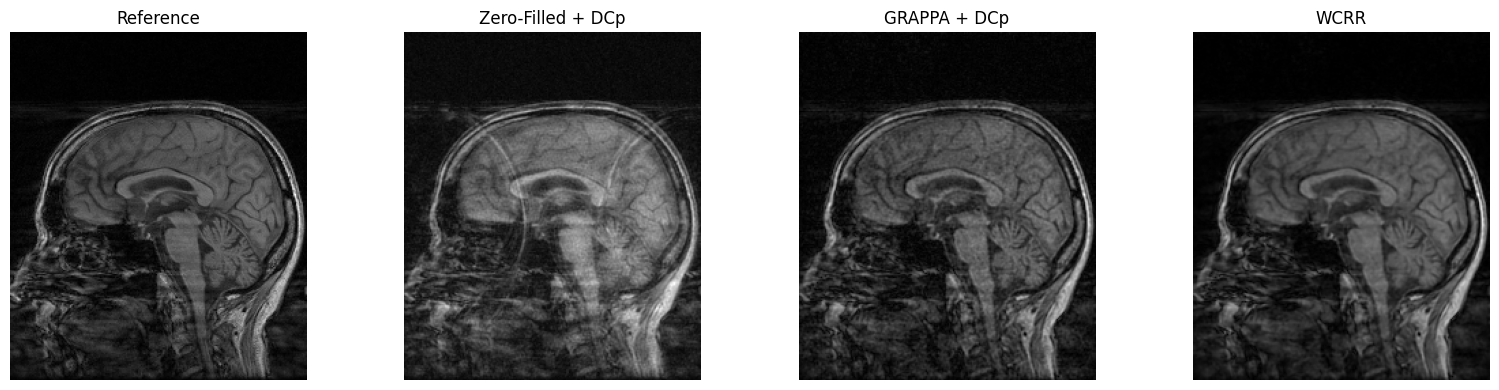

In [9]:
# Plots (sagittal mid-slice)
mid =  x.shape[-1] // 2
plt.figure(figsize=(16,4))
plt.subplot(1,4,1); plt.imshow(reference[..., mid], cmap='gray'); plt.title('Reference'); plt.axis('off')
plt.subplot(1,4,2); plt.imshow(zf_recon[..., mid],  cmap='gray'); plt.title('Zero-Filled + DCp'); plt.axis('off')
plt.subplot(1,4,3); plt.imshow(grappa_recon[..., mid],  cmap='gray'); plt.title('GRAPPA + DCp'); plt.axis('off')
plt.subplot(1,4,4); plt.imshow(wcrr_recon[..., mid],  cmap='gray'); plt.title('WCRR'); plt.axis('off')
plt.tight_layout(); plt.show()

### Metric plots (for each iterative method)

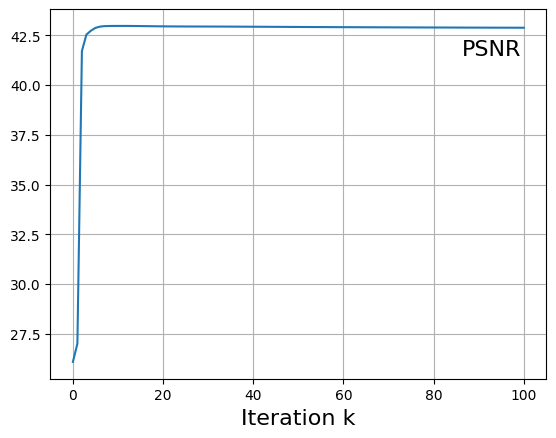

In [50]:
#plt.plot(wv_metrics['psnr'][0], label=r"$\ell_1$-wavelet")
#plt.plot(tv_metrics['psnr'][0], label=r"TV")
plt.plot(wcrr_metrics['psnr'])#, label=r"WCRR")
#plt.plot(drunet_metrics['psnr'][0], label=r"PnP-DRUNet")
plt.grid(True)
plt.xlabel("Iteration k", fontsize=16)
plt.ylabel(r"PSNR", fontsize=16, rotation=0, ha="right", va="top")
plt.gca().yaxis.set_label_coords(0.95, 0.92)
#plt.savefig(f"savings/psnrs_32coil_example.pdf", bbox_inches='tight')
plt.show()

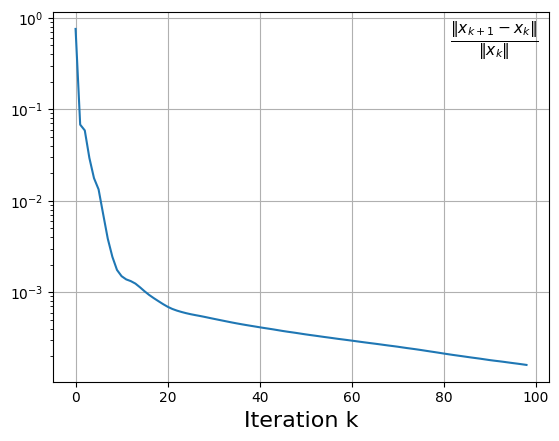

In [51]:
import math
#plt.plot([math.log(r) for r in wv_metrics['residual'][0]], label=r"$\ell_1$-wavelet")
#plt.plot([math.log(r) for r in tv_metrics['residual'][0]], label=r"TV")
plt.plot(wcrr_metrics['residual'])#, label=r"WCRR")
#plt.plot([math.log(r) for r in drunet_metrics['residual'][0]], label=r"PnP-DRUNet")
plt.grid(True)
plt.xlabel("Iteration k", fontsize=16)
plt.ylabel(r"$\frac{\|x_{k+1} - x_k \|}{\| x_k \|}$", fontsize=16, fontweight="bold", rotation=0, ha="right", va="top")
plt.gca().yaxis.set_label_coords(0.98, 0.98)
plt.yscale("log")
#plt.savefig(f"savings/residuals_32coil_example.pdf", bbox_inches='tight')
plt.show()

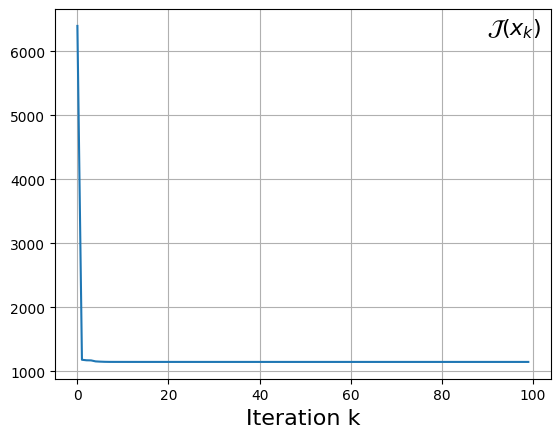

In [54]:
#plt.plot(wv_metrics['cost'][0], label=r"$\ell_1$-wavelet")
#plt.plot(tv_metrics['cost'][0], label=r"TV")
plt.plot(wcrr_metrics['cost'])#, label=r"WCRR")
#plt.plot(drunet_metrics['cost'][0], label=r"PnP-DRUNet")
plt.grid(True)
plt.xlabel("Iteration k", fontsize=16)
plt.ylabel(r"$\mathcal{J}(x_k)$", fontsize=16, fontweight="bold", rotation=0, ha="right", va="top")
plt.gca().yaxis.set_label_coords(0.98, 0.98)
#plt.savefig(f"savings/energies_32coil_example.pdf", bbox_inches='tight')
plt.show()

In [42]:
os.remove("../wcrr-noncartesian-3d-mri/weights/score_for_Denoising/CRR_score_training_for_Denoising.pt")

In [51]:
import shutil

#shutil.rmtree("../wcrr-noncartesian-3d-mri/hyperparameters_tuning/")